In [1]:

from pathlib import Path
import os
import sys
import re
import time
import math
import json
import yaml
from glob import glob
from typing import Any, Dict, Optional

import cv2
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Bootstrap: RGMC project root
# =========================================================
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (
            (p / "src").exists()
            and (p / "configs").exists()
            and (p / "data").exists()
            and (p / "exec").exists()
        ):
            return p
    raise RuntimeError(
        f"Directory does not exists. start={start}, "
        "expected markers: src/, configs/, data/, exec/."
    )

CWD = Path.cwd().resolve()
PROJECT_ROOT = find_project_root(CWD)

SRC_ROOT = PROJECT_ROOT / "src"
CONFIG_ROOT = PROJECT_ROOT / "configs"
DATA_ROOT = PROJECT_ROOT / "data"
EXEC_ROOT = EXEC_ROOT / "exec"

TASK2_DIR = SRC_ROOT / "task2"
CALIBRATION_DIR = SRC_ROOT / "calibration"
COMMON_CAMERA_DIR = SRC_ROOT / "common" / "camera"
CLOUDGRIPPER_CLIENT_DIR = SRC_ROOT / "cloudgripper-api" / "client"

print("CWD                :", CWD)
print("PROJECT_ROOT       :", PROJECT_ROOT)
print("SRC_ROOT           :", SRC_ROOT, SRC_ROOT.exists())
print("TASK2_DIR          :", TASK2_DIR, TASK2_DIR.exists())
print("CALIBRATION_DIR    :", CALIBRATION_DIR, CALIBRATION_DIR.exists())
print("COMMON_CAMERA_DIR  :", COMMON_CAMERA_DIR, COMMON_CAMERA_DIR.exists())
print("CLOUDGRIPPER_DIR   :", CLOUDGRIPPER_CLIENT_DIR, CLOUDGRIPPER_CLIENT_DIR.exists())
print("CONFIG_ROOT        :", CONFIG_ROOT)
print("DATA_ROOT          :", DATA_ROOT)

# =========================================================
# .env load
# =========================================================
try:
    from dotenv import load_dotenv
    ENV_PATH = PROJECT_ROOT / ".env"
    load_dotenv(ENV_PATH)
    print("dotenv loaded from:", ENV_PATH)
except Exception as e:
    print("dotenv not used:", repr(e))

# =========================================================
# sys.path
# =========================================================
desired_paths = [
    str(TASK2_DIR),
    str(SRC_ROOT),
    str(CALIBRATION_DIR),
    str(COMMON_CAMERA_DIR),
    str(CLOUDGRIPPER_CLIENT_DIR),
]
for p in reversed(desired_paths):
    if p in sys.path:
        sys.path.remove(p)
    sys.path.insert(0, p)

# =========================================================
# Imports
# =========================================================
from cloudgripper_client import GripperRobot
from pixel_to_workspace import PixelToWorkspaceMapper
from calibration.detector import YOLOGripperDetector
from rope_closed_loop_real_mpc_compute_only import (
    build_compute_only_planner,
    compute_mpc_action,
    mean_node_error_mm,
    rmse_mm,
)

# =========================================================
# User settings
# =========================================================
CLOUDGRIPPER_TOKEN = os.getenv("CLOUDGRIPPER_TOKEN")
if not CLOUDGRIPPER_TOKEN:
    raise RuntimeError("CLOUDGRIPPER_TOKEN not set.")

# =========================================================
# Direct robot mode
# - competition_status(), competition_start()를 사용하지 않는다.
# - 아래 ROBOT_ID만 바꾸면 robotN 접속 및 관련 LUT/config 파일을 로드한다.
# =========================================================
ROBOT_ID = 20                  # 예: 9 -> robot9. 실행할 로봇 번호로 수정
ROBOT_NAME = f"robot{int(ROBOT_ID)}"

USE_LIVE_ROBOT = True
DO_ENV_RESET = True
DO_EVAL_START = True          # eval_start가 필요한 환경이면 True로 변경

EXPECTED_NUM_NODES = 20
REVERSE_NODE_ORDER = True
GRASPABLE_INDEX_MIN = 3
GRASPABLE_INDEX_MAX = 19
GRASP_ANGLE_WINDOW = 2

MAX_STEPS = 100
STOP_MEAN_ERROR_MM = 6.0

# task2 collector 기준 fallback action bounds
DEFAULT_ACTION_X_MIN, DEFAULT_ACTION_X_MAX = 0.10, 0.84
DEFAULT_ACTION_Y_MIN, DEFAULT_ACTION_Y_MAX = 0.00, 1.00

# motion / timing (collector보다 약간 빠르게)
Z_PICK = 0.05
Z_SAFE = 0.30

WAIT_AFTER_MOVE_XY = 0.30
WAIT_AFTER_MOVE_Z_SAFE = 0.25
WAIT_AFTER_MOVE_Z_PICK = 0.45
WAIT_AFTER_GRIPPER_CLOSE = 0.35
WAIT_AFTER_DRAG_XY = 0.60
WAIT_AFTER_GRIPPER_OPEN = 0.45
WAIT_AFTER_ROTATE = 0.20
WAIT_AFTER_RELEASE_SETTLE = 0.50

OBS_RETRY_COUNT = 3
OBS_RETRY_SLEEP = 0.35

# direct robot / LUT / homography / detector
LUT_CANDIDATE_DIR = DATA_ROOT / "lut_candidates"
HOMOGRAPHY_SIDECAR_DIR = DATA_ROOT / "lut_homography_sidecars"
LUT_GLOB = "lut_robot*.pkl"

# task1 middle eval에서 사용하던 gripper detector model
GRIPPER_DETECTOR_MODEL_PATH = SRC_ROOT / "models" / "last.pt"

# planner model
TASK2_MODEL_PATH = TASK2_DIR / "graphdlo_residual_model_exp2.pt"
if not TASK2_MODEL_PATH.exists():
    raise FileNotFoundError(f"Task2 model not found: {TASK2_MODEL_PATH}")

ENABLE_HOMOGRAPHY_FALLBACK = True
HOMOGRAPHY_FALLBACK_CLAMP = False
HOMOGRAPHY_FALLBACK_VERBOSE = True
HOMOGRAPHY_FALLBACK_MAX_LOG = 10

print("LUT_CANDIDATE_DIR       :", LUT_CANDIDATE_DIR)
print("HOMOGRAPHY_SIDECAR_DIR  :", HOMOGRAPHY_SIDECAR_DIR)
print("GRIPPER_DETECTOR_MODEL  :", GRIPPER_DETECTOR_MODEL_PATH)
print("TASK2_MODEL_PATH        :", TASK2_MODEL_PATH)

# =========================================================
# Utility helpers
# =========================================================
def pretty_print(obj, title=None):
    if title:
        print(f"\n[{title}]")
    import pprint
    pprint.pprint(obj)

def show_bgr(img, title="image", figsize=(6, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def sleep_cmd(sec):
    time.sleep(float(sec))

def get_undistorted_image(robot):
    out = robot.getImageBaseUndistorted()
    if isinstance(out, tuple):
        img_proc, ts_img = out
    else:
        img_proc, ts_img = out, None

    if not isinstance(img_proc, np.ndarray):
        raise TypeError(
            f"Expected np.ndarray from robot.getImageBaseUndistorted(), got {type(img_proc)}"
        )
    return img_proc, ts_img

def unpack_robot_state_out(state_out):
    if isinstance(state_out, tuple):
        state, ts = state_out
    else:
        state, ts = state_out, None
    return state, ts

def get_robot_xy_from_state(state):
    return [float(state["x_norm"]), float(state["y_norm"])]

def get_stable_robot_state(
    robot,
    max_tries=8,
    interval=0.20,
    tol=0.01,
    required_consecutive=2,
):
    samples = []
    prev_xy = None
    stable_count = 0
    last_state = None
    last_ts = None

    for k in range(int(max_tries)):
        state_out = robot.get_state()
        state, ts = unpack_robot_state_out(state_out)
        xy = get_robot_xy_from_state(state)

        samples.append({
            "try": int(k + 1),
            "xy": [float(xy[0]), float(xy[1])],
            "ts": ts,
        })

        if prev_xy is not None:
            dist = float(np.hypot(xy[0] - prev_xy[0], xy[1] - prev_xy[1]))
            if dist <= float(tol):
                stable_count += 1
            else:
                stable_count = 0

            if stable_count >= int(required_consecutive):
                return state, ts, True, samples

        prev_xy = xy
        last_state = state
        last_ts = ts

        if k < int(max_tries) - 1:
            time.sleep(float(interval))

    return last_state, last_ts, False, samples

# =========================================================
# Robot / LUT / workspace / homography helpers
# =========================================================
def _iter_nested(obj):
    if isinstance(obj, dict):
        for k, v in obj.items():
            yield k
            yield from _iter_nested(v)
    elif isinstance(obj, (list, tuple)):
        for item in obj:
            yield from _iter_nested(item)
    elif obj is not None:
        yield obj

def find_first_robot_name(obj: Any) -> Optional[str]:
    pat = re.compile(r"robot\d+", re.IGNORECASE)
    for v in _iter_nested(obj):
        s = str(v)
        m = pat.search(s)
        if m:
            robot_name = m.group(0).lower()
            digits = "".join(ch for ch in robot_name if ch.isdigit())
            return f"robot{int(digits)}"
    return None

def try_extract_assigned_robot_name(obj):
    if obj is None:
        return None
    candidate_keys = [
        "robot",
        "robot_name",
        "assigned_robot",
        "assigned_robot_name",
        "worker",
        "worker_name",
        "robot_id",
        "worker_id",
    ]
    if isinstance(obj, dict):
        for k in candidate_keys:
            v = obj.get(k)
            if isinstance(v, str) and len(v) > 0:
                digits = "".join(ch for ch in v if ch.isdigit())
                if digits:
                    return f"robot{int(digits)}"
                return v.lower()
    return find_first_robot_name(obj)

def normalize_robot_name(value):
    if value is None:
        return None
    s = str(value).strip()
    if not s:
        return None
    digits = "".join(ch for ch in s if ch.isdigit())
    if digits:
        return f"robot{int(digits)}"
    return s.lower()

def parse_robot_name_from_lut_filename(path: Path):
    stem = path.stem
    parts = stem.split("robot")
    if len(parts) < 2:
        raise ValueError(f"robot id parse failed from LUT filename: {path.name}")
    suffix = parts[-1]
    return f"robot{suffix}"

def load_workspace_bounds_from_calibration_yaml(yaml_path: Path):
    yaml_path = Path(yaml_path)
    if not yaml_path.exists():
        raise FileNotFoundError(f"Calibration yaml not found: {yaml_path}")

    with open(yaml_path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)

    if not isinstance(data, dict):
        raise RuntimeError(f"Calibration yaml must load to dict: {yaml_path}")

    section_candidates = [
        "rope_calibration",
        "calibration",
        "task2_calibration",
        "task1_calibration",
        "planar_push_calibration",
    ]

    section_name = None
    section = None
    for name in section_candidates:
        cand = data.get(name, None)
        if isinstance(cand, dict) and all(k in cand for k in ["x_min", "x_max", "y_min", "y_max"]):
            section_name = name
            section = cand
            break

    if section is None:
        raise RuntimeError(
            f"x_min/x_max/y_min/y_max not found in calibration yaml: {yaml_path}"
        )

    x_min = float(section["x_min"])
    x_max = float(section["x_max"])
    y_min = float(section["y_min"])
    y_max = float(section["y_max"])

    if not (x_min < x_max and y_min < y_max):
        raise ValueError(
            f"Invalid workspace bounds in {yaml_path}: "
            f"x=({x_min}, {x_max}), y=({y_min}, {y_max})"
        )

    action_x_min = float(section.get("action_x_min", DEFAULT_ACTION_X_MIN))
    action_x_max = float(section.get("action_x_max", DEFAULT_ACTION_X_MAX))
    action_y_min = float(section.get("action_y_min", DEFAULT_ACTION_Y_MIN))
    action_y_max = float(section.get("action_y_max", DEFAULT_ACTION_Y_MAX))

    return {
        "section_name": section_name,
        "x_min": x_min,
        "x_max": x_max,
        "y_min": y_min,
        "y_max": y_max,
        "action_x_min": action_x_min,
        "action_x_max": action_x_max,
        "action_y_min": action_y_min,
        "action_y_max": action_y_max,
    }

def load_precomputed_homography_for_candidate(candidate):
    sidecar_path = Path(candidate["sidecar_path"])
    if not sidecar_path.exists():
        raise FileNotFoundError(f"Homography sidecar not found: {sidecar_path}")

    data = np.load(sidecar_path, allow_pickle=True)
    if "H_uv_to_xy" not in data:
        raise RuntimeError(f"'H_uv_to_xy' not found in sidecar: {sidecar_path}")

    H = np.asarray(data["H_uv_to_xy"], dtype=np.float64)
    if H.shape != (3, 3) or not np.isfinite(H).all():
        raise RuntimeError(f"Invalid homography matrix in {sidecar_path}: shape={H.shape}")

    info = {
        "sidecar_path": str(sidecar_path),
        "num_pairs": int(data["num_pairs"]) if "num_pairs" in data else None,
        "rmse_mean": float(data["rmse_mean"]) if "rmse_mean" in data else None,
        "rmse_max": float(data["rmse_max"]) if "rmse_max" in data else None,
        "source_kind": str(data["source_kind"]) if "source_kind" in data else None,
        "source_desc": str(data["source_desc"]) if "source_desc" in data else None,
    }
    return H, info

def _apply_homography_uv_to_xy(H, u, v, x_min, x_max, y_min, y_max):
    pt = np.array([float(u), float(v), 1.0], dtype=np.float64)
    proj = H @ pt
    w = float(proj[2])
    if abs(w) < 1e-12:
        raise RuntimeError(f"Homography projection is singular at (u={u}, v={v})")

    x = float(proj[0] / w)
    y = float(proj[1] / w)

    if HOMOGRAPHY_FALLBACK_CLAMP:
        x = float(np.clip(x, x_min, x_max))
        y = float(np.clip(y, y_min, y_max))

    return x, y

def _patch_mapper_convert_one_with_homography_fallback(mapper, H, x_min, x_max, y_min, y_max):
    original_convert_one = mapper.convert_one

    def _convert_one_with_fallback(self, u, v, *args, **kwargs):
        try:
            return original_convert_one(u, v, *args, **kwargs)
        except Exception as e:
            msg = str(e).lower()
            if ("outside" not in msg) and ("hull" not in msg):
                raise

            x_h, y_h = _apply_homography_uv_to_xy(H, u, v, x_min, x_max, y_min, y_max)

            count = getattr(self, "_homography_fallback_count", 0) + 1
            setattr(self, "_homography_fallback_count", count)

            if HOMOGRAPHY_FALLBACK_VERBOSE and count <= HOMOGRAPHY_FALLBACK_MAX_LOG:
                print(
                    f"[homography fallback #{count}] "
                    f"(u={float(u):.2f}, v={float(v):.2f}) -> "
                    f"(x={x_h:.4f}, y={y_h:.4f})"
                )
            return float(x_h), float(y_h)

    mapper._original_convert_one = original_convert_one
    mapper.convert_one = _convert_one_with_fallback.__get__(mapper, type(mapper))

def attach_homography_fallback_to_candidate(candidate):
    if candidate.get("homography_ready", False):
        return candidate["mapper"]

    H_UV_TO_XY, pre_info = load_precomputed_homography_for_candidate(candidate)

    workspace_cfg = candidate["workspace_cfg"]
    mapper = candidate["mapper"]

    _patch_mapper_convert_one_with_homography_fallback(
        mapper,
        H_UV_TO_XY,
        workspace_cfg["x_min"], workspace_cfg["x_max"],
        workspace_cfg["y_min"], workspace_cfg["y_max"],
    )

    candidate["homography_ready"] = True
    candidate["homography_info"] = {
        "enabled": True,
        "source": f"precomputed: {pre_info['sidecar_path']}",
        "num_pairs": pre_info.get("num_pairs"),
        "rmse_mean": pre_info.get("rmse_mean"),
        "rmse_max": pre_info.get("rmse_max"),
        "source_kind": pre_info.get("source_kind"),
        "source_desc": pre_info.get("source_desc"),
        "sidecar_path": pre_info.get("sidecar_path"),
        "H": H_UV_TO_XY,
    }

    print(
        f"[precomputed homography attached] {candidate['robot_name']} | "
        f"sidecar={pre_info['sidecar_path']} | "
        f"pairs={pre_info.get('num_pairs')} | "
        f"rmse_mean={pre_info.get('rmse_mean')} | "
        f"rmse_max={pre_info.get('rmse_max')}"
    )
    return mapper

def build_candidate_record(lut_path: Path):
    robot_name = parse_robot_name_from_lut_filename(lut_path)
    robot_digits = "".join(ch for ch in robot_name if ch.isdigit())
    if not robot_digits:
        raise ValueError(f"robot id parse failed from {robot_name}")

    robot_map_dir = DATA_ROOT / "map" / robot_name
    calibration_yaml_path = CONFIG_ROOT / "calibration" / f"calibration_{robot_name}.yaml"
    param_file_candidate = CONFIG_ROOT / "camera" / f"camera-params-cr{int(robot_digits):02d}.yaml"
    param_file = param_file_candidate if param_file_candidate.exists() else None

    workspace_cfg = load_workspace_bounds_from_calibration_yaml(calibration_yaml_path)

    mapper = PixelToWorkspaceMapper(
        str(lut_path),
        clamp_to_workspace=False,
        x_min=workspace_cfg["x_min"], x_max=workspace_cfg["x_max"],
        y_min=workspace_cfg["y_min"], y_max=workspace_cfg["y_max"],
    )

    sidecar_path = HOMOGRAPHY_SIDECAR_DIR / f"{Path(lut_path).stem}_homography.npz"

    return {
        "robot_name": robot_name,
        "robot_digits": robot_digits,
        "lut_path": Path(lut_path),
        "robot_map_dir": robot_map_dir,
        "calibration_yaml_path": calibration_yaml_path,
        "param_file": param_file,
        "workspace_cfg": workspace_cfg,
        "mapper": mapper,
        "sidecar_path": sidecar_path,
        "homography_ready": False,
        "homography_info": None,
    }

def preload_lut_candidates():
    lut_paths = sorted(Path(p) for p in glob(str(LUT_CANDIDATE_DIR / LUT_GLOB)))
    if len(lut_paths) == 0:
        raise FileNotFoundError(f"No LUT candidates found in {LUT_CANDIDATE_DIR / LUT_GLOB}")

    candidates = []
    errors = []
    for lut_path in lut_paths:
        try:
            rec = build_candidate_record(lut_path)
            candidates.append(rec)
        except Exception as e:
            errors.append((str(lut_path), repr(e)))

    if len(candidates) == 0:
        raise RuntimeError(f"All LUT candidate preload failed: {errors}")

    print(f"preloaded {len(candidates)} LUT candidates")
    for c in candidates:
        print(
            f" - {c['robot_name']} | {c['lut_path'].name} | "
            f"bounds=({c['workspace_cfg']['x_min']:.3f},{c['workspace_cfg']['x_max']:.3f},"
            f"{c['workspace_cfg']['y_min']:.3f},{c['workspace_cfg']['y_max']:.3f}) | "
            f"sidecar={'yes' if c['sidecar_path'].exists() else 'missing'}"
        )

    if len(errors) > 0:
        print("\n[preload skipped candidates]")
        for p, e in errors:
            print(" -", p, "->", e)

    return candidates

def _select_homography_sidecar_path(robot_name: str, robot_map_dir: Path, lut_path: Path) -> Path:
    """Return the most likely precomputed homography sidecar path.

    Priority:
    1. data/lut_homography_sidecars/lut_robotN_homography.npz
    2. data/lut_homography_sidecars/<lut_stem>_homography.npz
    3. data/map/robotN/lut_homography.npz
    """
    sidecar_candidates = [
        HOMOGRAPHY_SIDECAR_DIR / f"lut_{robot_name}_homography.npz",
        HOMOGRAPHY_SIDECAR_DIR / f"{Path(lut_path).stem}_homography.npz",
        Path(robot_map_dir) / "lut_homography.npz",
    ]

    for p in sidecar_candidates:
        if p.exists():
            return p

    # Keep a deterministic default path so the later error message is explicit.
    return sidecar_candidates[0]


def build_direct_robot_record(robot_id_or_name):
    """Build one robot context from an explicit robot id/name.

    This is the direct-mode replacement for competition LUT auto-selection.
    It loads:
      - data/map/robotN/lut.pkl
      - configs/calibration/calibration_robotN.yaml
      - configs/camera/camera-params-crNN.yaml  (optional; only needed for local undistortion/debug)

    If data/map/robotN/lut.pkl is missing, it falls back to:
      - data/lut_candidates/lut_robotN.pkl
    """
    robot_name = normalize_robot_name(robot_id_or_name)
    if robot_name is None:
        raise ValueError(f"Invalid robot id/name: {robot_id_or_name}")

    robot_digits = "".join(ch for ch in robot_name if ch.isdigit())
    if not robot_digits:
        raise ValueError(f"robot id parse failed from {robot_id_or_name}")

    robot_id = int(robot_digits)
    robot_name = f"robot{robot_id}"

    robot_map_dir = DATA_ROOT / "map" / robot_name
    primary_lut_path = robot_map_dir / "lut.pkl"
    fallback_lut_path = LUT_CANDIDATE_DIR / f"lut_{robot_name}.pkl"

    if primary_lut_path.exists():
        lut_path = primary_lut_path
        lut_source = "robot_map_dir"
    elif fallback_lut_path.exists():
        lut_path = fallback_lut_path
        lut_source = "lut_candidates_fallback"
    else:
        raise FileNotFoundError(
            "LUT file not found for direct robot mode. Checked:\n"
            f"  - {primary_lut_path}\n"
            f"  - {fallback_lut_path}"
        )

    calibration_yaml_path = CONFIG_ROOT / "calibration" / f"calibration_{robot_name}.yaml"
    param_file_candidate = CONFIG_ROOT / "camera" / f"camera-params-cr{robot_id:02d}.yaml"
    param_file = param_file_candidate if param_file_candidate.exists() else None

    if not calibration_yaml_path.exists():
        raise FileNotFoundError(f"Calibration yaml not found: {calibration_yaml_path}")
    if param_file is None:
        print(f"[camera yaml skipped] not found and not required because getImageBaseUndistorted() is used: {param_file_candidate}")

    workspace_cfg = load_workspace_bounds_from_calibration_yaml(calibration_yaml_path)

    mapper = PixelToWorkspaceMapper(
        str(lut_path),
        clamp_to_workspace=False,
        x_min=workspace_cfg["x_min"],
        x_max=workspace_cfg["x_max"],
        y_min=workspace_cfg["y_min"],
        y_max=workspace_cfg["y_max"],
    )

    sidecar_path = _select_homography_sidecar_path(robot_name, robot_map_dir, lut_path)

    return {
        "robot_name": robot_name,
        "robot_digits": str(robot_id),
        "robot_map_dir": robot_map_dir,
        "lut_path": Path(lut_path),
        "lut_source": lut_source,
        "calibration_yaml_path": calibration_yaml_path,
        "param_file": param_file,
        "workspace_cfg": workspace_cfg,
        "mapper": mapper,
        "sidecar_path": sidecar_path,
        "homography_ready": False,
        "homography_info": None,
    }


# Direct robot mode에서는 모든 LUT 후보를 미리 로드하지 않는다.
# scipy 미설치/후보 LUT 누락 때문에 노트북 시작이 실패하는 문제를 피하기 위함.
LUT_CANDIDATES = []


def find_candidate_by_robot_name(robot_name):
    target = normalize_robot_name(robot_name)
    if target is None:
        return None

    for c in LUT_CANDIDATES:
        cand_norm = normalize_robot_name(c["robot_name"])
        if cand_norm == target:
            return c

    # Direct mode fallback: build the requested robot context lazily.
    try:
        return build_direct_robot_record(target)
    except Exception:
        return None

# =========================================================
# Gripper center detector for passive LUT selection
# =========================================================
if not GRIPPER_DETECTOR_MODEL_PATH.exists():
    raise FileNotFoundError(f"Detector model file not found: {GRIPPER_DETECTOR_MODEL_PATH}")

gripper_detector = YOLOGripperDetector(
    model_path=str(GRIPPER_DETECTOR_MODEL_PATH),
    conf=0.25,
    min_area=100,
    target_class=None,
    prefer_center=True,
)
print("gripper_detector ready")

def detect_gripper_center_uv(img_bgr):
    pred = gripper_detector.predict(img_bgr)
    if (not pred.get("ok")) or (pred.get("center_uv") is None):
        raise RuntimeError(f"gripper center detect failed: {pred}")
    u, v = pred["center_uv"]
    return float(u), float(v), pred

def score_lut_candidate(mapper, uv, xy_cmd):
    x_hat, y_hat = mapper.convert_one(float(uv[0]), float(uv[1]))
    dx = float(x_hat - xy_cmd[0])
    dy = float(y_hat - xy_cmd[1])
    err = float(np.hypot(dx, dy))
    return {
        "x_hat": float(x_hat),
        "y_hat": float(y_hat),
        "dx": dx,
        "dy": dy,
        "err": err,
    }

def get_passive_reference_observation(
    robot,
    capture_retries=3,
    num_frames=3,
    interval=0.15,
):
    state, state_ts, state_stable, state_samples = get_stable_robot_state(robot)
    true_xy = get_robot_xy_from_state(state)

    uv_samples = []
    pred_samples = []
    img_ts_samples = []
    errors = []

    for frame_idx in range(int(num_frames)):
        uv = None
        pred = None
        img_ts = None
        last_err = None

        for _ in range(int(capture_retries)):
            try:
                img, img_ts = get_undistorted_image(robot)
                u, v, pred = detect_gripper_center_uv(img)
                uv = (float(u), float(v))
                break
            except Exception as e:
                last_err = e
                time.sleep(0.1)

        if uv is not None:
            uv_samples.append(uv)
            pred_samples.append(pred)
            img_ts_samples.append(img_ts)
        else:
            errors.append(repr(last_err))

        if frame_idx < int(num_frames) - 1:
            time.sleep(float(interval))

    if len(uv_samples) == 0:
        raise RuntimeError(f"passive LUT selection failed: no valid gripper detections. errors={errors}")

    uv_arr = np.asarray(uv_samples, dtype=float)
    uv_mean = (float(np.mean(uv_arr[:, 0])), float(np.mean(uv_arr[:, 1])))

    return {
        "true_xy": [float(true_xy[0]), float(true_xy[1])],
        "uv_mean": [float(uv_mean[0]), float(uv_mean[1])],
        "uv_samples": [[float(u), float(v)] for u, v in uv_samples],
        "pred_samples": pred_samples,
        "img_ts_samples": img_ts_samples,
        "state_ts": state_ts,
        "state_stable": bool(state_stable),
        "state_samples": state_samples,
        "errors": errors,
    }

def rank_lut_candidates_from_reference(true_xy, uv):
    ranked = []
    for c in LUT_CANDIDATES:
        try:
            s = score_lut_candidate(c["mapper"], uv, true_xy)
            ranked.append({
                "candidate": c,
                "valid_count": 1,
                "median_err": float(s["err"]),
                "mean_err": float(s["err"]),
                "max_err": float(s["err"]),
                "scores": [s],
            })
        except Exception as e:
            ranked.append({
                "candidate": c,
                "valid_count": 0,
                "median_err": float("inf"),
                "mean_err": float("inf"),
                "max_err": float("inf"),
                "scores": [],
                "error": repr(e),
            })

    ranked.sort(
        key=lambda x: (
            -x["valid_count"],
            x["median_err"],
            x["mean_err"],
            x["max_err"],
        )
    )
    return ranked

def select_best_lut_passive(robot):
    reference = get_passive_reference_observation(robot)
    true_xy = tuple(reference["true_xy"])
    uv_mean = tuple(reference["uv_mean"])

    print("\n[PASSIVE LUT SELECTION]")
    print("true_xy :", true_xy)
    print("uv_mean :", uv_mean)
    print("state_stable:", reference["state_stable"])
    print("uv_samples :", reference["uv_samples"])

    ranked = rank_lut_candidates_from_reference(true_xy, uv_mean)
    if len(ranked) == 0 or ranked[0]["valid_count"] == 0:
        raise RuntimeError("No valid LUT candidate ranked in passive selection")

    print("\n[LUT ranking | passive]")
    for r in ranked:
        c = r["candidate"]
        extra = ""
        if r.get("error") is not None:
            extra = f" | error={r['error']}"
        print(
            f" - {c['robot_name']:>8s} | valid={r['valid_count']} "
            f"| err={r['mean_err']:.6f}{extra}"
        )

    best = ranked[0]
    probe_logs = [{
        "mode": "passive",
        "true_xy": reference["true_xy"],
        "uv_mean": reference["uv_mean"],
        "uv_samples": reference["uv_samples"],
        "pred_samples": reference["pred_samples"],
        "img_ts_samples": reference["img_ts_samples"],
        "state_ts": reference["state_ts"],
        "state_stable": reference["state_stable"],
        "state_samples": reference["state_samples"],
        "errors": reference["errors"],
    }]

    print("\n[SELECTED LUT | passive]")
    c = best["candidate"]
    print("robot_name :", c["robot_name"])
    print("lut_path   :", c["lut_path"])
    print("mean_err   :", best["mean_err"])

    return best, ranked, probe_logs

def choose_lut_context(preferred_robot_name, robot):
    preferred_norm = normalize_robot_name(preferred_robot_name)

    if preferred_norm is not None:
        direct_candidate = find_candidate_by_robot_name(preferred_norm)
        if direct_candidate is not None:
            print(f"[LUT] direct robot match available: {preferred_norm}")
            return (
                {
                    "candidate": direct_candidate,
                    "valid_count": 1,
                    "median_err": 0.0,
                    "mean_err": 0.0,
                    "max_err": 0.0,
                    "scores": [],
                    "selection_method": "direct_assigned_robot",
                },
                [],
                [{
                    "mode": "direct_assigned_robot",
                    "preferred_robot_name": preferred_robot_name,
                    "normalized_robot_name": preferred_norm,
                }],
            )

        print(f"[LUT] robot hint received but LUT missing: {preferred_norm}")
        print("[LUT] falling back to passive LUT selection")

    best, ranked, probe_logs = select_best_lut_passive(robot)
    best["selection_method"] = "passive_best_available"
    return best, ranked, probe_logs

# =========================================================
# Task2 rope helpers
# =========================================================
def extract_geometry_points(result, reverse_order=True):
    if result is None:
        raise RuntimeError("result is None")

    coord_space = result.get("coordinate_space", None)
    geom = result.get("geometry", {})

    points_like = None
    if isinstance(geom, dict):
        if "segmented_points" in geom:
            points_like = geom["segmented_points"]
        elif "points" in geom:
            points_like = geom["points"]

    if points_like is None:
        raise RuntimeError(f"Could not find geometry points in result keys={list(result.keys())}")

    if len(points_like) == 0:
        raise RuntimeError("Empty points payload")

    first = points_like[0]
    if isinstance(first, dict):
        uv = np.array([[float(p["x"]), float(p["y"])] for p in points_like], dtype=np.float32)
    else:
        uv = np.array([[float(p[0]), float(p[1])] for p in points_like], dtype=np.float32)

    if reverse_order:
        uv = uv[::-1].copy()

    return uv, coord_space

def safe_convert_uv_points(mapper, uv_points):
    uv_points = np.asarray(uv_points, dtype=np.float32)
    xy = np.full((len(uv_points), 2), np.nan, dtype=np.float32)
    valid_mask = np.zeros((len(uv_points),), dtype=bool)
    error_msgs = [None] * len(uv_points)

    for i, p in enumerate(uv_points):
        u, v = float(p[0]), float(p[1])
        try:
            x, y = mapper.convert_one(u, v)
            x = float(x)
            y = float(y)
            if not np.isfinite(x) or not np.isfinite(y):
                raise RuntimeError(f"Non-finite mapper output for ({u}, {v}) -> ({x}, {y})")
            xy[i] = [x, y]
            valid_mask[i] = True
        except Exception as e:
            error_msgs[i] = repr(e)

    return xy, valid_mask, error_msgs

def convert_uv_points_with_homography(H, uv_points, x_min, x_max, y_min, y_max, clamp=False):
    uv_points = np.asarray(uv_points, dtype=np.float64)
    xy = np.full((len(uv_points), 2), np.nan, dtype=np.float32)
    valid_mask = np.zeros((len(uv_points),), dtype=bool)
    inside_workspace_mask = np.zeros((len(uv_points),), dtype=bool)

    if H is None:
        return xy, valid_mask, inside_workspace_mask

    for i, (u, v) in enumerate(uv_points):
        try:
            x, y = _apply_homography_uv_to_xy(H, u, v, x_min, x_max, y_min, y_max)
            if clamp:
                x = float(np.clip(x, x_min, x_max))
                y = float(np.clip(y, y_min, y_max))
            xy[i] = [x, y]
            valid_mask[i] = np.isfinite(x) and np.isfinite(y)
            inside_workspace_mask[i] = (x_min <= x <= x_max) and (y_min <= y <= y_max)
        except Exception:
            pass

    return xy, valid_mask, inside_workspace_mask

def compare_xy_ext_vs_lut_local(xy_ext, xy_lut, lut_valid_mask):
    xy_ext = np.asarray(xy_ext, dtype=np.float32)
    xy_lut = np.asarray(xy_lut, dtype=np.float32)
    lut_valid_mask = np.asarray(lut_valid_mask, dtype=bool)

    common = lut_valid_mask & np.isfinite(xy_ext).all(axis=1)
    if common.sum() == 0:
        return {
            "n_common_valid": 0,
            "mean_err": None,
            "max_err": None,
        }

    err = np.linalg.norm(xy_ext[common] - xy_lut[common], axis=1)
    return {
        "n_common_valid": int(common.sum()),
        "mean_err": float(np.mean(err)),
        "max_err": float(np.max(err)),
    }

def get_rope_observation(robot, candidate):
    raw = robot.eval_object()
    uv_full, coord_space = extract_geometry_points(raw, reverse_order=REVERSE_NODE_ORDER)

    if len(uv_full) != EXPECTED_NUM_NODES:
        raise RuntimeError(f"Expected {EXPECTED_NUM_NODES} rope nodes, got {len(uv_full)}")

    mapper = candidate["mapper"]
    ws = candidate["workspace_cfg"]
    H = None
    if candidate.get("homography_info") is not None:
        H = candidate["homography_info"].get("H")

    xy_lut_full, lut_valid_mask_full, lut_error_msgs_full = safe_convert_uv_points(mapper, uv_full)
    xy_ext_full, xy_ext_valid_mask_full, xy_ext_inside_workspace_mask_full = convert_uv_points_with_homography(
        H=H,
        uv_points=uv_full,
        x_min=ws["x_min"],
        x_max=ws["x_max"],
        y_min=ws["y_min"],
        y_max=ws["y_max"],
        clamp=False,
    )

    if H is None:
        xy_ext_full = xy_lut_full.copy()
        xy_ext_valid_mask_full = lut_valid_mask_full.copy()
        xy_ext_inside_workspace_mask_full = (
            (xy_ext_full[:, 0] >= ws["x_min"])
            & (xy_ext_full[:, 0] <= ws["x_max"])
            & (xy_ext_full[:, 1] >= ws["y_min"])
            & (xy_ext_full[:, 1] <= ws["y_max"])
            & np.isfinite(xy_ext_full).all(axis=1)
        )

    xy_ext_vs_lut_metrics = compare_xy_ext_vs_lut_local(
        xy_ext=xy_ext_full,
        xy_lut=xy_lut_full,
        lut_valid_mask=lut_valid_mask_full,
    )

    img_bgr, img_ts = get_undistorted_image(robot)

    return {
        "raw": raw,
        "coord_space": coord_space,
        "uv_full": uv_full,
        "xy_lut_full": xy_lut_full,
        "lut_valid_mask_full": lut_valid_mask_full,
        "lut_error_msgs_full": lut_error_msgs_full,
        "xy_ext_full": xy_ext_full,
        "xy_ext_valid_mask_full": xy_ext_valid_mask_full,
        "xy_ext_inside_workspace_mask_full": xy_ext_inside_workspace_mask_full,
        "xy_ext_vs_lut_metrics": xy_ext_vs_lut_metrics,
        "image_bgr": img_bgr,
        "image_ts": img_ts,
    }

def get_target_observation(robot, candidate):
    raw = robot.eval_target()
    uv_full, coord_space = extract_geometry_points(raw, reverse_order=REVERSE_NODE_ORDER)

    if len(uv_full) != EXPECTED_NUM_NODES:
        raise RuntimeError(f"Expected {EXPECTED_NUM_NODES} target nodes, got {len(uv_full)}")

    mapper = candidate["mapper"]
    ws = candidate["workspace_cfg"]
    H = None
    if candidate.get("homography_info") is not None:
        H = candidate["homography_info"].get("H")

    xy_lut_full, lut_valid_mask_full, lut_error_msgs_full = safe_convert_uv_points(mapper, uv_full)
    xy_ext_full, xy_ext_valid_mask_full, xy_ext_inside_workspace_mask_full = convert_uv_points_with_homography(
        H=H,
        uv_points=uv_full,
        x_min=ws["x_min"],
        x_max=ws["x_max"],
        y_min=ws["y_min"],
        y_max=ws["y_max"],
        clamp=False,
    )

    if H is None:
        xy_ext_full = xy_lut_full.copy()
        xy_ext_valid_mask_full = lut_valid_mask_full.copy()
        xy_ext_inside_workspace_mask_full = (
            (xy_ext_full[:, 0] >= ws["x_min"])
            & (xy_ext_full[:, 0] <= ws["x_max"])
            & (xy_ext_full[:, 1] >= ws["y_min"])
            & (xy_ext_full[:, 1] <= ws["y_max"])
            & np.isfinite(xy_ext_full).all(axis=1)
        )

    xy_ext_vs_lut_metrics = compare_xy_ext_vs_lut_local(
        xy_ext=xy_ext_full,
        xy_lut=xy_lut_full,
        lut_valid_mask=lut_valid_mask_full,
    )

    return {
        "raw": raw,
        "coord_space": coord_space,
        "uv_full": uv_full,
        "xy_lut_full": xy_lut_full,
        "lut_valid_mask_full": lut_valid_mask_full,
        "lut_error_msgs_full": lut_error_msgs_full,
        "xy_ext_full": xy_ext_full,
        "xy_ext_valid_mask_full": xy_ext_valid_mask_full,
        "xy_ext_inside_workspace_mask_full": xy_ext_inside_workspace_mask_full,
        "xy_ext_vs_lut_metrics": xy_ext_vs_lut_metrics,
    }

def retry_obs(fn, n_retry=OBS_RETRY_COUNT, retry_sleep=OBS_RETRY_SLEEP):
    last_err = None
    for k in range(n_retry):
        try:
            return fn()
        except Exception as e:
            last_err = e
            print(f"[obs retry {k+1}/{n_retry}] {repr(e)}")
            if k < n_retry - 1:
                time.sleep(retry_sleep)
    raise last_err

def compute_grasp_theta_deg_from_uv_window(uv_full, node_idx, window=2):
    pts = np.asarray(uv_full, dtype=np.float32)
    n = len(pts)

    if n < 2:
        raise ValueError("Need at least 2 rope points")

    max_expand = max(window, n - 1)
    for w in range(window, max_expand + 1):
        left = max(0, node_idx - w)
        right = min(n - 1, node_idx + w)

        if right <= left:
            continue

        p0 = pts[left]
        p1 = pts[right]

        du = float(p1[0] - p0[0])
        dv = float(p1[1] - p0[1])

        if math.hypot(du, dv) > 1e-6:
            theta_deg = math.degrees(math.atan2(dv, du)) % 180.0
            return float(theta_deg)

    raise RuntimeError(f"Failed to estimate grasp angle for node_idx={node_idx}")

def quantize_rotate_deg(theta_deg):
    theta = float(theta_deg) % 180.0
    theta_int = int(round(theta))
    if theta_int >= 180:
        theta_int = 0
    return int(theta_int)

def ensure_robot_safe(robot):
    robot.gripper_open()
    sleep_cmd(WAIT_AFTER_GRIPPER_OPEN)
    robot.move_z(float(Z_SAFE))
    sleep_cmd(WAIT_AFTER_MOVE_Z_SAFE)

def execute_rope_drag(robot, grasp_xy, target_xy, candidate, rotate_before_pick_deg=None):
    ws = candidate["workspace_cfg"]

    gx = float(np.clip(grasp_xy[0], ws["action_x_min"], ws["action_x_max"]))
    gy = float(np.clip(grasp_xy[1], ws["action_y_min"], ws["action_y_max"]))
    tx = float(np.clip(target_xy[0], ws["action_x_min"], ws["action_x_max"]))
    ty = float(np.clip(target_xy[1], ws["action_y_min"], ws["action_y_max"]))

    robot.move_z(float(Z_SAFE))
    sleep_cmd(WAIT_AFTER_MOVE_Z_SAFE)

    if rotate_before_pick_deg is not None:
        robot.rotate(int(rotate_before_pick_deg))
        sleep_cmd(WAIT_AFTER_ROTATE)

    robot.gripper_open()
    sleep_cmd(0.20)

    robot.move_xy(gx, gy)
    sleep_cmd(WAIT_AFTER_MOVE_XY)

    robot.move_z(float(Z_PICK))
    sleep_cmd(WAIT_AFTER_MOVE_Z_PICK)

    robot.gripper_close()
    sleep_cmd(WAIT_AFTER_GRIPPER_CLOSE)

    robot.move_xy(tx, ty)
    sleep_cmd(WAIT_AFTER_DRAG_XY)

    robot.gripper_open()
    sleep_cmd(WAIT_AFTER_GRIPPER_OPEN)

    robot.move_z(float(Z_SAFE))
    sleep_cmd(WAIT_AFTER_MOVE_Z_SAFE)

def plot_uv_and_xy(current_obs, target_obs, title="current vs target"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.imshow(cv2.cvtColor(current_obs["image_bgr"], cv2.COLOR_BGR2RGB))
    ax.plot(current_obs["uv_full"][:, 0], current_obs["uv_full"][:, 1], "o-", label="current_uv")
    ax.plot(target_obs["uv_full"][:, 0], target_obs["uv_full"][:, 1], "o-", label="target_uv")
    ax.set_title(title + " | UV")
    ax.legend()
    ax.axis("off")

    ax = axes[1]
    ax.plot(current_obs["xy_ext_full"][:, 0], current_obs["xy_ext_full"][:, 1], "o-", label="current_xy_ext")
    ax.plot(target_obs["xy_ext_full"][:, 0], target_obs["xy_ext_full"][:, 1], "o-", label="target_xy_ext")
    ax.set_title(title + " | XY_EXT")
    ax.grid(True, linestyle=":")
    ax.set_aspect("equal")
    ax.legend()

    plt.tight_layout()
    plt.show()

print("Cell 1 ready")


CWD                : C:\Users\USER\Desktop\김보형\로봇\9주차\RGMC (직선,L,ㄷ,astar인데_경우줄임) - 네모,원,T\notebooks\task2
PROJECT_ROOT       : C:\Users\USER\Desktop\김보형\로봇\9주차\RGMC (직선,L,ㄷ,astar인데_경우줄임) - 네모,원,T
SRC_ROOT           : C:\Users\USER\Desktop\김보형\로봇\9주차\RGMC (직선,L,ㄷ,astar인데_경우줄임) - 네모,원,T\src True
TASK2_DIR          : C:\Users\USER\Desktop\김보형\로봇\9주차\RGMC (직선,L,ㄷ,astar인데_경우줄임) - 네모,원,T\src\task2 True
CALIBRATION_DIR    : C:\Users\USER\Desktop\김보형\로봇\9주차\RGMC (직선,L,ㄷ,astar인데_경우줄임) - 네모,원,T\src\calibration True
COMMON_CAMERA_DIR  : C:\Users\USER\Desktop\김보형\로봇\9주차\RGMC (직선,L,ㄷ,astar인데_경우줄임) - 네모,원,T\src\common\camera True
CLOUDGRIPPER_DIR   : C:\Users\USER\Desktop\김보형\로봇\9주차\RGMC (직선,L,ㄷ,astar인데_경우줄임) - 네모,원,T\src\cloudgripper_api\client True
CONFIG_ROOT        : C:\Users\USER\Desktop\김보형\로봇\9주차\RGMC (직선,L,ㄷ,astar인데_경우줄임) - 네모,원,T\configs
DATA_ROOT          : C:\Users\USER\Desktop\김보형\로봇\9주차\RGMC (직선,L,ㄷ,astar인데_경우줄임) - 네모,원,T\data
dotenv loaded from: C:\Users\USER\Desktop\김보형\로봇\9주차\RGMC (직

[ROBOT CONNECTION]
ROBOT_ID       : 20
ROBOT_NAME     : robot20
robot state    : {'x_norm': 0.5075, 'y_norm': 0.04057142857142857, 'z_norm': 0.050000000000000044, 'rotation': 3, 'claw_norm': 0.0, 'z_current': '0.01', 'rotation_current': '-0.10', 'claw_current': '-0.05'}
state_hint_ts  : 1777466028.4809978
[camera yaml skipped] not found and not required because getImageBaseUndistorted() is used: C:\Users\USER\Desktop\김보형\로봇\9주차\RGMC (직선,L,ㄷ,astar인데_경우줄임) - 네모,원,T\configs\camera\camera-params-cr20.yaml
[precomputed homography attach failed] FileNotFoundError('Homography sidecar not found: C:\\Users\\USER\\Desktop\\김보형\\로봇\\9주차\\RGMC (직선,L,ㄷ,astar인데_경우줄임) - 네모,원,T\\data\\lut_homography_sidecars\\lut_robot20_homography.npz')

[SELECTED ROBOT MAP CONTEXT]
ROBOT_NAME             : robot20
ROBOT_ID               : 20
LUT_PATH               : C:\Users\USER\Desktop\김보형\로봇\9주차\RGMC (직선,L,ㄷ,astar인데_경우줄임) - 네모,원,T\data\map\robot20\lut.pkl True
LUT_SOURCE             : robot_map_dir
ROBOT_MAP_DIR 

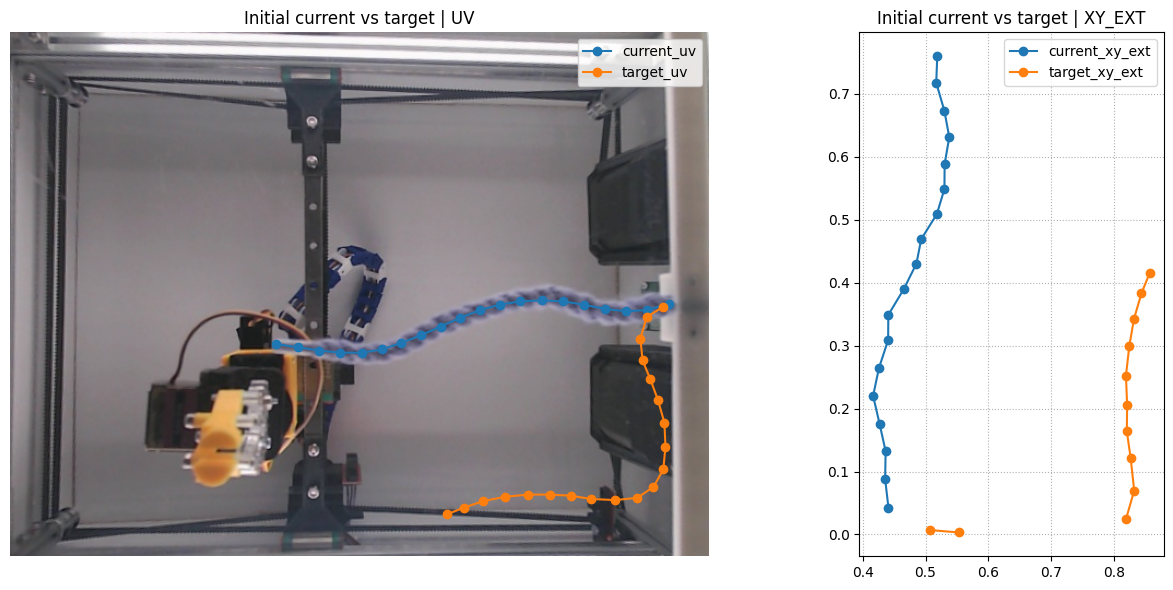


[STEP 1/100]
Undistorted image not available
[obs retry 1/3] TypeError("Expected np.ndarray from robot.getImageBaseUndistorted(), got <class 'NoneType'>")
before_mean_err_mm = nan
before_rmse_mm     = nan
[MPC] total feasible candidates: 1721
[MPC] shortlist by cheap score: 3 / 1721
[MPC] cheap top summary:
  #1 | node= 3 | len=0.0824 | theta_deg= -36.31 | cheap=2.0105 | cos=1.0000 | over=-0.0300 | margin=-0.0000
  #2 | node= 3 | len=0.0822 | theta_deg= -36.39 | cheap=2.0105 | cos=1.0000 | over=-0.0300 | margin=0.0000
  #3 | node= 3 | len=0.0837 | theta_deg= -35.71 | cheap=2.0104 | cos=1.0000 | over=-0.0300 | margin=-0.0000
[MPC]   expensive eval   3/3 done
[MPC] final top-k summary:
  #1 | node= 3 | len=0.0824 | theta_deg= -36.31 | cost=nan | shape=nan | key=nan | tan=nan | curv=nan | mean_err_mm=nan | rmse_mm=nan
  #2 | node= 3 | len=0.0822 | theta_deg= -36.39 | cost=nan | shape=nan | key=nan | tan=nan | curv=nan | mean_err_mm=nan | rmse_mm=nan
  #3 | node= 3 | len=0.0837 | theta_de

In [ ]:
# =========================================================
# Direct robot-id connect / LUT+map select / Task2 run
# =========================================================

ROBOT_NAME = f"robot{int(ROBOT_ID)}"

if USE_LIVE_ROBOT:
    robot = GripperRobot(ROBOT_NAME, token=CLOUDGRIPPER_TOKEN)
else:
    raise RuntimeError("Mock robot path/config is not set in this notebook.")

state_hint_out = robot.get_state()
state_hint, state_hint_ts = unpack_robot_state_out(state_hint_out)

print("[ROBOT CONNECTION]")
print("ROBOT_ID       :", ROBOT_ID)
print("ROBOT_NAME     :", ROBOT_NAME)
print("robot state    :", state_hint)
print("state_hint_ts  :", state_hint_ts)

# =========================================================
# Load the exact robot map/LUT/config from ROBOT_ID
# =========================================================

SELECTED_CANDIDATE = build_direct_robot_record(ROBOT_ID)

if ENABLE_HOMOGRAPHY_FALLBACK:
    try:
        attach_homography_fallback_to_candidate(SELECTED_CANDIDATE)
    except Exception as e:
        print("[precomputed homography attach failed]", repr(e))
        SELECTED_CANDIDATE["homography_ready"] = False
        SELECTED_CANDIDATE["homography_info"] = {
            "enabled": False,
            "error": repr(e),
        }

ROBOT_NAME = SELECTED_CANDIDATE["robot_name"]
ROBOT_ID = int(SELECTED_CANDIDATE["robot_digits"])
LUT_PATH = Path(SELECTED_CANDIDATE["lut_path"])
ROBOT_MAP_DIR = SELECTED_CANDIDATE["robot_map_dir"]
CALIBRATION_YAML_PATH = SELECTED_CANDIDATE["calibration_yaml_path"]
PARAM_FILE = SELECTED_CANDIDATE.get("param_file")
workspace_cfg = SELECTED_CANDIDATE["workspace_cfg"]
mapper = SELECTED_CANDIDATE["mapper"]

print("\n[SELECTED ROBOT MAP CONTEXT]")
print("ROBOT_NAME             :", ROBOT_NAME)
print("ROBOT_ID               :", ROBOT_ID)
print("LUT_PATH               :", LUT_PATH, LUT_PATH.exists())
print("LUT_SOURCE             :", SELECTED_CANDIDATE.get("lut_source"))
print("ROBOT_MAP_DIR          :", ROBOT_MAP_DIR, ROBOT_MAP_DIR.exists())
print("CALIBRATION_YAML_PATH  :", CALIBRATION_YAML_PATH, CALIBRATION_YAML_PATH.exists())
print("PARAM_FILE             :", PARAM_FILE if PARAM_FILE is not None else "not used / not found")
print("SIDECAR_PATH           :", SELECTED_CANDIDATE.get("sidecar_path"))
print("workspace yaml section :", workspace_cfg["section_name"])
print("X_MIN, X_MAX           :", workspace_cfg["x_min"], workspace_cfg["x_max"])
print("Y_MIN, Y_MAX           :", workspace_cfg["y_min"], workspace_cfg["y_max"])
print("ACTION_X_MIN, ACTION_X_MAX :", workspace_cfg["action_x_min"], workspace_cfg["action_x_max"])
print("ACTION_Y_MIN, ACTION_Y_MAX :", workspace_cfg["action_y_min"], workspace_cfg["action_y_max"])
print("homography_ready       :", SELECTED_CANDIDATE.get("homography_ready"))
print("homography_info        :", SELECTED_CANDIDATE.get("homography_info"))

planner = build_compute_only_planner(
    model_path=str(TASK2_MODEL_PATH),
    graspable_index_min=GRASPABLE_INDEX_MIN,
    graspable_index_max=GRASPABLE_INDEX_MAX,
    action_x_min=workspace_cfg["action_x_min"],
    action_x_max=workspace_cfg["action_x_max"],
    action_y_min=workspace_cfg["action_y_min"],
    action_y_max=workspace_cfg["action_y_max"],
)

print("task2 planner ready")

if DO_ENV_RESET:
    ensure_robot_safe(robot)
    reset_out = robot.env_reset()
    pretty_print(reset_out, "env_reset")
    time.sleep(1.2)

if DO_EVAL_START:
    eval_out = robot.eval_start()
    pretty_print(eval_out, "eval_start")
    time.sleep(0.4)

# target는 시작 시 한 번 읽고 고정
target_obs = retry_obs(lambda: get_target_observation(robot, SELECTED_CANDIDATE))
print("target coord_space:", target_obs["coord_space"])
print("target xy_ext_vs_lut:", target_obs["xy_ext_vs_lut_metrics"])

current_obs = retry_obs(lambda: get_rope_observation(robot, SELECTED_CANDIDATE))
print("current coord_space:", current_obs["coord_space"])
print("current xy_ext_vs_lut:", current_obs["xy_ext_vs_lut_metrics"])

plot_uv_and_xy(current_obs, target_obs, title="Initial current vs target")

history = []
success = False

for step_idx in range(1, MAX_STEPS + 1):
    print("\n" + "=" * 90)
    print(f"[STEP {step_idx}/{MAX_STEPS}]")
    print("=" * 90)

    before_obs = retry_obs(lambda: get_rope_observation(robot, SELECTED_CANDIDATE))
    current_points = np.asarray(before_obs["xy_ext_full"], dtype=np.float32)
    goal_points = np.asarray(target_obs["xy_ext_full"], dtype=np.float32)

    before_mean = mean_node_error_mm(current_points, goal_points)
    before_rmse = rmse_mm(current_points, goal_points)
    print(f"before_mean_err_mm = {before_mean:.3f}")
    print(f"before_rmse_mm     = {before_rmse:.3f}")

    out = compute_mpc_action(
        planner=planner,
        current_points=current_points,
        goal_points=goal_points,
        topk=3,
        shortlist_k=3,
        verbose=True,
    )

    node_idx = int(out["node_idx"])
    grasp_xy = np.asarray(out["grasp_xy"], dtype=np.float32)
    target_xy = np.asarray(out["target_xy"], dtype=np.float32)

    grasp_theta_deg = compute_grasp_theta_deg_from_uv_window(
        uv_full=before_obs["uv_full"],
        node_idx=node_idx,
        window=GRASP_ANGLE_WINDOW,
    )
    grasp_theta_cmd_deg = quantize_rotate_deg(grasp_theta_deg)

    print("selected node_idx          :", node_idx)
    print("selected grasp_xy          :", grasp_xy)
    print("selected target_xy         :", target_xy)
    print("predicted_mean_err_mm      :", out["predicted_mean_err_mm"])
    print("predicted_rmse_mm          :", out["predicted_rmse_mm"])
    print("grasp_theta_deg            :", grasp_theta_deg)
    print("grasp_theta_cmd_deg        :", grasp_theta_cmd_deg)

    execute_rope_drag(
        robot=robot,
        grasp_xy=grasp_xy,
        target_xy=target_xy,
        candidate=SELECTED_CANDIDATE,
        rotate_before_pick_deg=grasp_theta_cmd_deg,
    )
    sleep_cmd(WAIT_AFTER_RELEASE_SETTLE)

    after_obs = retry_obs(lambda: get_rope_observation(robot, SELECTED_CANDIDATE))
    after_points = np.asarray(after_obs["xy_ext_full"], dtype=np.float32)

    after_mean = mean_node_error_mm(after_points, goal_points)
    after_rmse = rmse_mm(after_points, goal_points)

    print(f"after_mean_err_mm  = {after_mean:.3f}")
    print(f"after_rmse_mm      = {after_rmse:.3f}")
    print("after xy_ext_vs_lut:", after_obs["xy_ext_vs_lut_metrics"])

    history.append(
        {
            "step_idx": int(step_idx),
            "node_idx": int(node_idx),
            "grasp_xy": grasp_xy.copy(),
            "target_xy": target_xy.copy(),
            "before_mean_err_mm": float(before_mean),
            "after_mean_err_mm": float(after_mean),
            "before_obs": before_obs,
            "after_obs": after_obs,
        }
    )

    plot_uv_and_xy(after_obs, target_obs, title=f"After step {step_idx}")

    if after_mean <= STOP_MEAN_ERROR_MM:
        success = True
        print(f"[STOP] reached threshold: {after_mean:.3f} mm <= {STOP_MEAN_ERROR_MM:.3f} mm")
        break

final_obs = history[-1]["after_obs"] if history else current_obs
final_points = np.asarray(final_obs["xy_ext_full"], dtype=np.float32)
goal_points = np.asarray(target_obs["xy_ext_full"], dtype=np.float32)

summary = {
    "success": bool(success),
    "num_steps": int(len(history)),
    "final_mean_err_mm": float(mean_node_error_mm(final_points, goal_points)),
    "final_rmse_mm": float(rmse_mm(final_points, goal_points)),
    "selected_robot_name": ROBOT_NAME,
    "robot_id": int(ROBOT_ID),
    "lut_path": str(LUT_PATH),
    "sidecar_path": str(SELECTED_CANDIDATE.get("sidecar_path")),
    "homography_ready": bool(SELECTED_CANDIDATE.get("homography_ready")),
}

print("\n[SUMMARY]")
print(json.dumps(summary, indent=2, ensure_ascii=False))


In [ ]:
robot.eval_object()

eval_object failed: Rope detection failed: no rope points found


In [ ]:
robot.eval_status()

{'status': 'completed',
 'final_score': 0.12,
 'message': 'Environment resetting.',
 'score_history': [{'t': 0.87, 'score': 0.12},
  {'t': 2.69, 'score': 0.12},
  {'t': 4.51, 'score': 0.13},
  {'t': 6.3, 'score': 0.12},
  {'t': 8.15, 'score': 0.13},
  {'t': 10.07, 'score': 0.12},
  {'t': 11.95, 'score': 0.13},
  {'t': 13.74, 'score': 0.13},
  {'t': 15.59, 'score': 0.13},
  {'t': 17.41, 'score': 0.12},
  {'t': 19.24, 'score': 0.12},
  {'t': 21.05, 'score': 0.13},
  {'t': 22.87, 'score': 0.13},
  {'t': 24.74, 'score': 0.13},
  {'t': 26.58, 'score': 0.13},
  {'t': 28.42, 'score': 0.13},
  {'t': 30.26, 'score': 0.13},
  {'t': 32.09, 'score': 0.12},
  {'t': 33.96, 'score': 0.13},
  {'t': 35.82, 'score': 0.13},
  {'t': 37.71, 'score': 0.13},
  {'t': 39.54, 'score': 0.13},
  {'t': 41.39, 'score': 0.13},
  {'t': 43.34, 'score': 0.13},
  {'t': 45.2, 'score': 0.12},
  {'t': 47.0, 'score': 0.13},
  {'t': 48.84, 'score': 0.13},
  {'t': 50.71, 'score': 0.13},
  {'t': 52.54, 'score': 0.13},
  {'t': 